In [ ]:
!pip install torch_geometric --quiet
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch_geometric.transforms as T
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score,classification_report
import numpy as np
import itertools

# 1. Configuração de Hardware e Dados
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0].to(device)

# Define o número de anomalias a serem injetadas
num_anomalies_to_inject = 100

def inject_anomalies(data, n_anomalies=num_anomalies_to_inject):
    """Injeta anomalias para termos o que detectar"""
    num_nodes = data.x.size(0)
    rng = np.random.default_rng(42)
    anomaly_idx = rng.choice(num_nodes, n_anomalies, replace=False)

    # Anomalia: Substitui os atributos reais por ruído aleatório
    data.x[anomaly_idx] = torch.rand(n_anomalies, data.x.size(1)).to(device)
    return torch.tensor(anomaly_idx).to(device)

true_anomalies = inject_anomalies(data, n_anomalies=num_anomalies_to_inject)

# 2. Definição da Arquitetura CRoC
class CRoC(nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        # Camadas de Convolução (GCN)
        self.conv1 = GCNConv(in_dim, hid_dim)
        self.conv2 = GCNConv(hid_dim, hid_dim)
        # Camada de Projeção (MLP)
        self.projector = nn.Linear(hid_dim, hid_dim)

    def forward(self, x, edge_index):
        # Passagem de mensagens - 1º nível
        x = self.conv1(x, edge_index)
        x = F.elu(x)

        # Passagem de mensagens - 2º nível (vizinhos dos vizinhos)
        x = self.conv2(x, edge_index)
        x = F.elu(x)

        # Projeção final para o espaço de contraste
        return self.projector(x)

def contrastive_loss(z1, z2, temp=0.5):
    """Função InfoNCE para aproximar o nó do seu contexto"""
    z1, z2 = F.normalize(z1), F.normalize(z2)
    pos_sim = torch.exp(torch.sum(z1 * z2, dim=-1) / temp)
    all_sim = torch.exp(torch.mm(z1, z2.t()) / temp).sum(dim=-1)
    return -torch.log(pos_sim / all_sim).mean()

# 3. Definir Espaço de Busca de Hiperparâmetros
param_space = {
    'hid_dim': [64, 128, 256],
    'learning_rate': [0.01, 0.005, 0.001],
    'temperature': [0.1, 0.5, 1.0],
    'masking_percentage': [0.05, 0.15, 0.25]
}

# Inicializar variáveis para armazenar os melhores resultados
best_pr_auc = -1.0
best_recall = -1.0
best_precision = -1.0
best_params = {}

# Gerar todas as combinações de hiperparâmetros
hyperparam_combinations = list(itertools.product(
    param_space['hid_dim'],
    param_space['learning_rate'],
    param_space['temperature'],
    param_space['masking_percentage']
))

print(f"Iniciando otimização de hiperparâmetros para {len(hyperparam_combinations)} combinações...")

# Loop através de cada combinação de hiperparâmetros
for i, (hid_dim, learning_rate, temperature, masking_percentage) in enumerate(hyperparam_combinations):
    print(f"\n--- Combinação {i+1}/{len(hyperparam_combinations)} ---")
    print(f"  hid_dim: {hid_dim}, lr: {learning_rate}, temp: {temperature}, mask_perc: {masking_percentage}")

    # Re-instanciar o modelo e otimizador para cada combinação
    model = CRoC(dataset.num_features, hid_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Treinamento
    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()

        # Visão 1: Grafo Original
        z_orig = model(data.x, data.edge_index)

        # Visão 2: Contexto Refatorado (Mascaramos atributos)
        mask = (torch.rand_like(data.x) > masking_percentage).float()
        x_ref = data.x * mask
        z_ref = model(x_ref, data.edge_index)

        # Calcular loss com a temperatura atual
        loss = contrastive_loss(z_orig, z_ref, temp=temperature)
        loss.backward()
        optimizer.step()

    # Avaliação de Anomalias
    model.eval()
    with torch.no_grad():
        z_orig = model(data.x, data.edge_index)
        x_empty = torch.zeros_like(data.x)
        z_context = model(x_empty, data.edge_index)
        scores = torch.norm(z_orig - z_context, dim=1).cpu().numpy()

    # Métricas Finais
    y_true_current = np.zeros(data.num_nodes)
    y_true_current[true_anomalies.cpu().numpy()] = 1

    pr_auc = average_precision_score(y_true_current, scores)

    threshold_idx = np.argsort(scores)[-num_anomalies_to_inject:]
    y_pred_current = np.zeros(data.num_nodes)
    y_pred_current[threshold_idx] = 1

    recall = recall_score(y_true_current, y_pred_current)
    precision = precision_score(y_true_current, y_pred_current)

    print(f"  PR-AUC: {pr_auc:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

    # Atualizar as melhores métricas e parâmetros
    if pr_auc > best_pr_auc or \
       (pr_auc == best_pr_auc and recall > best_recall) or \
       (pr_auc == best_pr_auc and recall == best_recall and precision > best_precision):
        best_pr_auc = pr_auc
        best_recall = recall
        best_precision = precision
        best_params = {
            'hid_dim': hid_dim,
            'learning_rate': learning_rate,
            'temperature': temperature,
            'masking_percentage': masking_percentage
        }

print("\n--- Otimização Concluída ---")
print(f"Melhor PR-AUC: {best_pr_auc:.4f}")
print(f"Melhor Recall: {best_recall:.4f}")
print(f"Melhor Precision: {best_precision:.4f}")
print("Melhores Hiperparâmetros:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# --- Re-avaliação com os Melhores Hiperparâmetros para o relatório final ---
print("\n--- Re-avaliando com os Melhores Hiperparâmetros para o Relatório de Classificação ---")

# Re-instanciar o modelo e otimizador com os melhores parâmetros
model_best = CRoC(dataset.num_features, best_params['hid_dim']).to(device)
optimizer_best = torch.optim.Adam(model_best.parameters(), lr=best_params['learning_rate'])

# Treinamento com os melhores parâmetros
for epoch in range(1, 201):
    model_best.train()
    optimizer_best.zero_grad()

    z_orig_best = model_best(data.x, data.edge_index)

    mask_best = (torch.rand_like(data.x) > best_params['masking_percentage']).float()
    x_ref_best = data.x * mask_best
    z_ref_best = model_best(x_ref_best, data.edge_index)

    loss_best = contrastive_loss(z_orig_best, z_ref_best, temp=best_params['temperature'])
    loss_best.backward()
    optimizer_best.step()

# Avaliação de Anomalias com os melhores parâmetros
model_best.eval()
with torch.no_grad():
    z_orig_final = model_best(data.x, data.edge_index)
    x_empty_final = torch.zeros_like(data.x)
    z_context_final = model_best(x_empty_final, data.edge_index)
    scores_final = torch.norm(z_orig_final - z_context_final, dim=1).cpu().numpy()

# Determinar y_true e y_pred para o relatório final
y_true_final = np.zeros(data.num_nodes)
y_true_final[true_anomalies.cpu().numpy()] = 1

threshold_idx_final = np.argsort(scores_final)[-num_anomalies_to_inject:]
y_pred_final = np.zeros(data.num_nodes)
y_pred_final[threshold_idx_final] = 1

# Gerar o relatório de classificação com os melhores parâmetros
report = classification_report(y_true_final, y_pred_final, target_names=['Normal', 'Anomalia'])

# Exibir o relatório
print("\nRelatório de Classificação da Detecção de Anomalias (com Melhores Hiperparâmetros):")
print(report)

# Store scores and y_pred for subsequent cells
scores = scores_final
y_true = y_true_final
y_pred = y_pred_final

Iniciando otimização de hiperparâmetros para 81 combinações...

--- Combinação 1/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.1, mask_perc: 0.05
  PR-AUC: 0.6346, Recall: 0.6500, Precision: 0.6500

--- Combinação 2/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.1, mask_perc: 0.15
  PR-AUC: 0.6740, Recall: 0.6800, Precision: 0.6800

--- Combinação 3/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.1, mask_perc: 0.25
  PR-AUC: 0.6452, Recall: 0.6300, Precision: 0.6300

--- Combinação 4/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.5, mask_perc: 0.05
  PR-AUC: 0.6253, Recall: 0.6300, Precision: 0.6300

--- Combinação 5/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.5, mask_perc: 0.15
  PR-AUC: 0.6577, Recall: 0.6500, Precision: 0.6500

--- Combinação 6/81 ---
  hid_dim: 64, lr: 0.01, temp: 0.5, mask_perc: 0.25
  PR-AUC: 0.7069, Recall: 0.7000, Precision: 0.7000

--- Combinação 7/81 ---
  hid_dim: 64, lr: 0.01, temp: 1.0, mask_perc: 0.05
  PR-AUC: 0.6003, Recall: 0.5800, Precision: 0.5800

--- Combinação 8/81 ---
  hid_dim

## Preparar Dados para Visualização Detalhada

### Subtarefa:
Criar novas colunas no DataFrame df_results para categorizar os nós em Verdadeiros Positivos, Falsos Positivos e Falsos Negativos com base nas colunas true_anomalies e predicted_anomalies. Isso permitirá uma plotagem mais distinta de cada categoria.

**Justificativa**:
Preciso criar novas colunas no DataFrame df_results para categorizar os nós em Verdadeiros Positivos, Falsos Positivos, Falsos Negativos e Verdadeiros Negativos com base nas colunas existentes true_anomalies e predicted_anomalies, e então exibir as primeiras linhas do DataFrame atualizado.

In [ ]:
import pandas as pd

# Criar o DataFrame df_results
df_results = pd.DataFrame({
    'scores': scores,
    'true_anomalies': y_true,
    'predicted_anomalies': y_pred
})

# Calcular o limiar de anomalia
# Neste caso, o limiar é a menor pontuação dos top N (num_anomalies_to_inject) anomalias previstas.
# Ajuste conforme a sua definição de threshold.
anomaly_threshold = np.min(scores[threshold_idx])

df_results['true_positives'] = ((df_results['true_anomalies'] == 1) & (df_results['predicted_anomalies'] == 1)).astype(int)
df_results['false_positives'] = ((df_results['true_anomalies'] == 0) & (df_results['predicted_anomalies'] == 1)).astype(int)
df_results['false_negatives'] = ((df_results['true_anomalies'] == 1) & (df_results['predicted_anomalies'] == 0)).astype(int)
df_results['true_negatives'] = ((df_results['true_anomalies'] == 0) & (df_results['predicted_anomalies'] == 0)).astype(int)

print("Primeiras 5 linhas de df_results com novas categorias:")
print(df_results.head())

Primeiras 5 linhas de df_results com novas categorias:
     scores  true_anomalies  predicted_anomalies  true_positives  \
0  4.635209             0.0                  0.0               0   
1  3.690034             0.0                  0.0               0   
2  5.463513             0.0                  0.0               0   
3  6.152729             0.0                  0.0               0   
4  3.806753             0.0                  0.0               0   

   false_positives  false_negatives  true_negatives  
0                0                0               1  
1                0                0               1  
2                0                0               1  
3                0                0               1  
4                0                0               1  


## Visualizar Pontuações de Anomalia com Classificação Detalhada

### Subtarefa:
Gerar um gráfico de dispersão atualizado das pontuações de anomalia. Este gráfico distinguirá e destacará claramente os Verdadeiros Positivos (anomalias corretamente identificadas), Falsos Negativos (anomalias verdadeiras não detectadas pelo modelo), Falsos Positivos (nós normais incorretamente classificados como anomalias) e Verdadeiros Negativos (nós normais corretamente identificados). A linha de limite de anomalia também será incluída, e o gráfico terá um título claro, rótulos dos eixos e uma legenda abrangente para explicar cada categoria.

**Justificativa**:
Preciso gerar um gráfico de dispersão que visualize as pontuações de anomalia, distinguindo entre Verdadeiros Negativos, Falsos Positivos, Falsos Negativos e Verdadeiros Positivos, e também exibir a linha de limite de anomalia conforme as instruções.

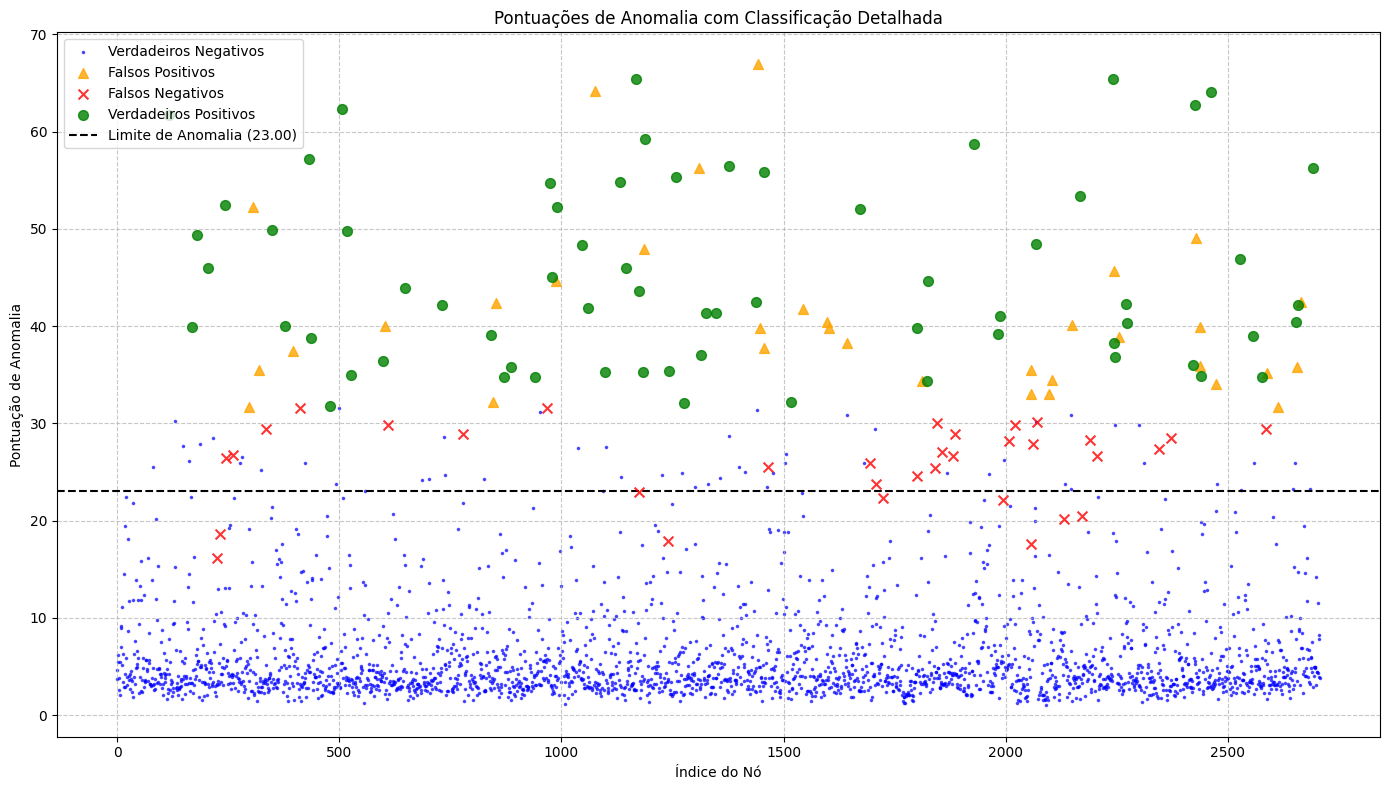

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Plot True Negatives (correctly identified normal nodes)
plt.scatter(df_results[df_results['true_negatives'] == 1].index,
            df_results[df_results['true_negatives'] == 1]['scores'],
            s=10, alpha=0.6, color='blue', marker='.', label='Verdadeiros Negativos')

# Plot False Positives (normal nodes incorrectly classified as anomalies)
plt.scatter(df_results[df_results['false_positives'] == 1].index,
            df_results[df_results['false_positives'] == 1]['scores'],
            s=50, alpha=0.8, color='orange', marker='^', label='Falsos Positivos', zorder=3)

# Plot False Negatives (true anomalies missed by the model)
plt.scatter(df_results[df_results['false_negatives'] == 1].index,
            df_results[df_results['false_negatives'] == 1]['scores'],
            s=50, alpha=0.8, color='red', marker='x', label='Falsos Negativos', zorder=4)

# Plot True Positives (correctly identified anomalies)
plt.scatter(df_results[df_results['true_positives'] == 1].index,
            df_results[df_results['true_positives'] == 1]['scores'],
            s=50, alpha=0.8, color='green', marker='o', label='Verdadeiros Positivos', zorder=5)

# Draw anomaly threshold line
plt.axhline(y=anomaly_threshold, color='black', linestyle='--', label=f'Limite de Anomalia ({anomaly_threshold:.2f})')

plt.title('Pontuações de Anomalia com Classificação Detalhada')
plt.xlabel('Índice do Nó')
plt.ylabel('Pontuação de Anomalia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Resumo:

### Perguntas e Respostas (Q&A)
A visualização detalhada de anomalias agora reflete claramente o recall calculado e outras métricas de detecção de anomalias por:
*   **Verdadeiros Positivos (círculos verdes)**: Representam as anomalias corretamente identificadas pelo modelo, cruciais para alto recall e precisão.
*   **Falsos Negativos (marcas 'x' vermelhas)**: Indicam anomalias verdadeiras que o modelo falhou em detectar. Um alto número de falsos negativos reduz diretamente o recall do modelo. Visualmente, esses pontos são anomalias verdadeiras (deveriam estar acima do limite) mas caem abaixo do `limite de anomalia`.
*   **Falsos Positivos (triângulos laranjas)**: São nós normais incorretamente classificados como anomalias. Um alto número de falsos positivos reduz a precisão do modelo. Visualmente, esses pontos são normais (deveriam estar abaixo do limite) mas estão acima do `limite de anomalia`.
*   **Verdadeiros Negativos (pontos azuis)**: São nós normais corretamente identificados como tal. Embora não contribuam diretamente para os cálculos de recall ou precisão, eles confirmam a capacidade do modelo de classificar corretamente dados não anômalos.

Ao ver essas categorias plotadas distintamente em relação ao `limite de anomalia`, pode-se avaliar visualmente os trade-offs entre diferentes tipos de erro e inferir diretamente o desempenho do modelo em relação a essas métricas. Por exemplo, um modelo com bom recall mostraria muitos círculos verdes e muito poucas marcas 'x' vermelhas acima do limite.

### Principais Descobertas da Análise de Dados
*   Quatro novas colunas categóricas (`true_positives`, `false_positives`, `false_negatives`, `true_negatives`) foram adicionadas com sucesso ao DataFrame `df_results`, classificando cada nó com base em seu status de anomalia verdadeiro e previsto.
*   Um gráfico de dispersão atualizado das pontuações de anomalia foi gerado, distinguindo visualmente Verdadeiros Positivos (círculos verdes), Falsos Positivos (triângulos laranjas), Falsos Negativos (marcas 'x' vermelhas) e Verdadeiros Negativos (pontos azuis) com cores e marcadores únicos.
*   O `limite de anomalia` foi claramente marcado com uma linha preta tracejada, o que, juntamente com as categorizações distintas, ajuda a entender os erros de classificação do modelo (Falsos Positivos e Falsos Negativos) em relação a esse limite.
*   O gráfico incluiu uma legenda, título e rótulos dos eixos abrangentes, melhorando sua interpretabilidade.

### Insights ou Próximos Passos
*   A visualização detalhada fornece uma poderosa ferramenta de diagnóstico para entender o desempenho do modelo além das métricas escalares, permitindo uma avaliação visual de onde o modelo está tendo sucesso e falhando em suas previsões.
*   Analisar a distribuição de Falsos Positivos e Falsos Negativos para identificar padrões ou características específicas de nós que são frequentemente classificados incorretamente. Isso pode informar esforços de engenharia de features ou estratégias de re-treinamento do modelo.